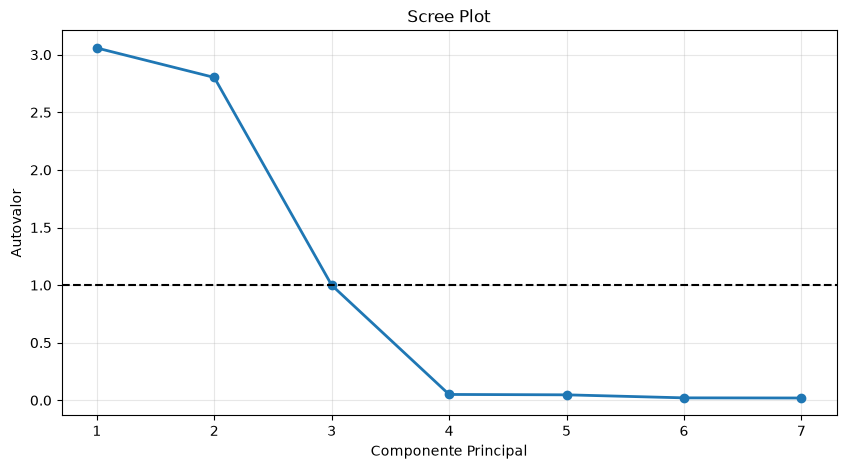

Autovalores:
[3.0584 2.8028 0.9993 0.0507 0.0475 0.0212 0.02  ]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Gerando dados de exemplo
# ==========================================================

np.random.seed(42)

n = 1000

# Dois fatores latentes
f1 = np.random.normal(size=n)
f2 = np.random.normal(size=n)

df = pd.DataFrame({
    "x1": 0.90 * f1 + np.random.normal(scale=0.10, size=n),
    "x2": 0.85 * f1 + np.random.normal(scale=0.15, size=n),
    "x3": 0.80 * f1 + np.random.normal(scale=0.20, size=n),

    "x4": 0.90 * f2 + np.random.normal(scale=0.10, size=n),
    "x5": 0.85 * f2 + np.random.normal(scale=0.15, size=n),
    "x6": 0.80 * f2 + np.random.normal(scale=0.20, size=n),

    # Variável praticamente independente
    "x7": np.random.normal(size=n)
})

# ==========================================================
# PCA via matriz de correlação
# ==========================================================

corr_matrix = df.corr()

# Autovalores
eigenvalues = np.linalg.eigvalsh(corr_matrix)

# Ordenar do maior para o menor
eigenvalues = np.sort(eigenvalues)[::-1]

# ==========================================================
# Scree Plot
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o",
    linewidth=2
)

# Linha λ = 1 (Critério de Kaiser)
plt.axhline(
    y=1,
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.xticks(range(1, len(eigenvalues) + 1))
plt.xlabel("Componente Principal")
plt.ylabel("Autovalor")
plt.title("Scree Plot")
plt.grid(alpha=0.3)

plt.show()

print("Autovalores:")
print(np.round(eigenvalues, 4))

In [10]:
df

,x1,x2,x3,x4,x5,x6,x7
0,0.379525,0.136036,0.224673,1.217044,1.022340,1.276521,-0.033025
1,-0.138890,-0.246582,-0.116852,0.786829,0.691299,0.384171,-0.503650
2,0.503678,0.488494,0.521754,-0.125897,-0.090623,0.190653,-0.172375
3,1.339931,1.577729,1.312950,-0.615252,-0.632096,-0.564294,0.714732
4,-0.400100,-0.115547,-0.460694,0.701684,0.561367,0.700070,1.277857
...,...,...,...,...,...,...,...
995,-0.245242,-0.234667,-0.234673,0.980282,0.864948,1.298091,0.101630
996,1.643693,1.216362,1.580431,0.091396,0.092812,0.044182,1.167218
997,0.452583,0.496672,1.135256,-0.915428,-0.828702,-0.872525,1.588447
998,-0.480643,-0.238995,-0.295336,-0.099965,-0.139373,0.200129,-0.684987
